In [14]:
"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""
import numpy as np
# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
# Hint: Use np.ones and array slicing
matrix = np.ones((5, 5))
matrix[1:-1, 1:-1]=0
print(matrix)


[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [15]:
# Task 2: Normalize a random array
# TODO: Normalize each column to have mean=0 and std=1

np.random.seed(42)
random_data = np.random.randn(100, 3)
mean=random_data.mean(axis=0)
std=random_data.std(axis=0)
Normalized = (random_data-mean)/std

print(mean)
print(std)
print(Normalized)

[ 0.09176598 -0.18323331  0.07482166]
[0.82066472 0.97419224 1.10733139]
[[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-01]
 [-5.81051242e-01 -5.06767212e-01  4.84818398e-01]
 [ 1.1444

In [16]:
# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# TODO: Calculate theta_hat using the normal equation
theta_hat= np.linalg.inv(X.T@X)@X.T@y
print(theta_hat)
print(true_theta)

[ 2.51723721 -1.19783796  3.72399266]
[ 2.5 -1.2  3.7]


In [25]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)
# TODO: Display basic information about the dataset
print(df.head(2))
print(df.info())
print(df.describe())
print(df.shape)
# TODO: Identify and count missing values
df.isnull().sum()
# TODO: Fill missing exam_score with the mean score for the student's major
for major in df['major'].unique():
    mean_score=df[df['major']==major]['exam_score'].mean()
    df.loc[(df['major']==major)&(df['exam_score'].isnull()),'exam_score']=mean_score
#
# TODO: Fill missing hours_studied with the median for the student's year
for year in df['year'].unique():
    median_hours=df[df['year']==year]['hours_studied'].median()
    df.loc[(df['year']==year)&(df['hours_studied'].isnull()),'hours_studied']=median_hours


   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.51

In [36]:
# Task 2: Analysis
# TODO: Calculate and display the average exam_score by major
average_exam_score=df.groupby('major')['exam_score'].mean()
print(average_exam_score)

# TODO: Find the major with the highest average exam_score
highest_average_exam_score=df.groupby('major')['exam_score'].mean().idxmax()
print(highest_average_exam_score)

# TODO: Calculate and display the average hours_studied by year
average_hours_studied=df.groupby('year')['hours_studied'].mean()
print(average_hours_studied)
# TODO: Calculate the correlation between hours_studied and exam_score
corr=df['hours_studied'].corr(df['exam_score'])
print(f"\correlation:{corr:.3f}")

# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)

def Score(score):
  if score>90:
    return 'Excellent'
  elif score>80:
    return 'Good'
  elif score>70:
    return 'Average'
  else:
    return 'Needs Improvement'

df['performance']=df['exam_score'].apply(Score)
print(df['performance'])


major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64
CS
year
1    14.401377
2    13.639938
3    14.626629
4    15.935764
Name: hours_studied, dtype: float64
\correlation:-0.056
0      Needs Improvement
1                Average
2                Average
3      Needs Improvement
4              Excellent
             ...        
195    Needs Improvement
196    Needs Improvement
197              Average
198              Average
199                 Good
Name: performance, Length: 200, dtype: object


<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_17806/3972081873.py:15: SyntaxWarning: invalid escape sequence '\c'
  print(f"\correlation:{corr:.3f}")


In [41]:
# Task 3: Advanced Analysis
# TODO: For each major and year combination, calculate:
#       - Number of students

groups=df.groupby(['major', 'year']).agg({'student_id':'count'})
print(groups)


#       - Average exam score
average_exam_score=df.groupby(['major', 'year'])['exam_score'].mean()
print(average_exam_score)


#       - Average hours studied
average_hours_studied=df.groupby(['major', 'year'])['hours_studied'].mean()
print(average_hours_studied)


# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
top_5_students = df.nlargest(5, 'exam_score')[['student_id', 'exam_score']]
print(top_5_students)

# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)
pivot= df.pivot_table(index='major', columns='year', values='exam_score')
print(pivot)

              student_id
major   year            
Biology 1             13
        2             12
        3             14
        4             15
CS      1             12
        2              7
        3              9
        4             18
Math    1             11
        2              9
        3             10
        4             16
Physics 1             13
        2             12
        3             17
        4             12
major    year
Biology  1       76.570059
         2       74.899613
         3       80.178476
         4       70.697689
CS       1       77.098194
         2       76.155936
         3       72.347626
         4       78.119997
Math     1       74.053167
         2       81.226714
         3       72.017537
         4       73.103066
Physics  1       77.828686
         2       73.277734
         3       73.134319
         4       78.130194
Name: exam_score, dtype: float64
major    year
Biology  1       12.677806
         2       13.426372
   

<Axes: xlabel='major', ylabel='exam_score'>

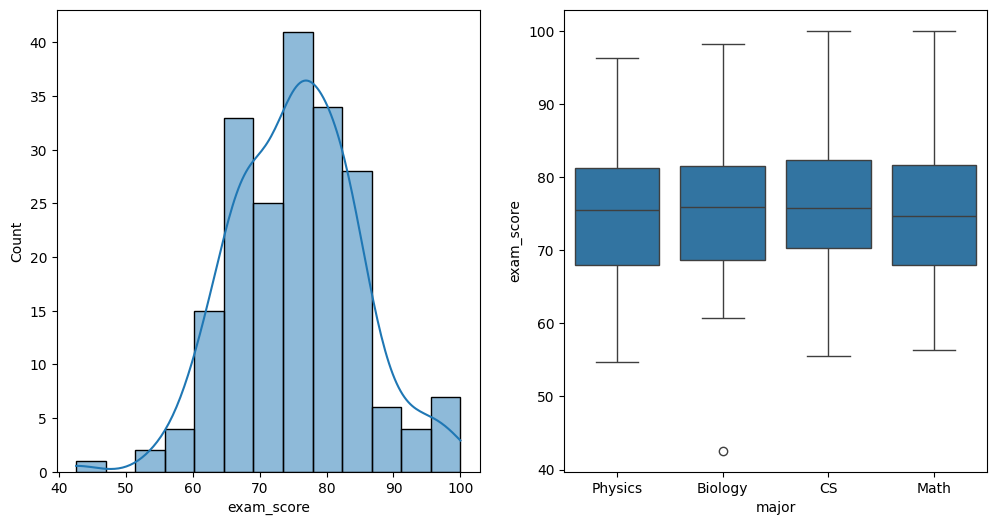

In [42]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Continue using the df from Exercise 5

# Task 1: Distribution Visualization (8 points)
# TODO: Create a figure with 2 subplots side by side
#       Right: Box plot of exam scores by major

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
#Left: Histogram of exam scores with KDE overlay
sns.histplot(df['exam_score'], kde=True, ax=axes[0])
#Right: Box plot of exam scores by major
sns.boxplot(x='major', y='exam_score', data=df, ax=axes[1])
#







<Axes: xlabel='hours_studied', ylabel='exam_score'>

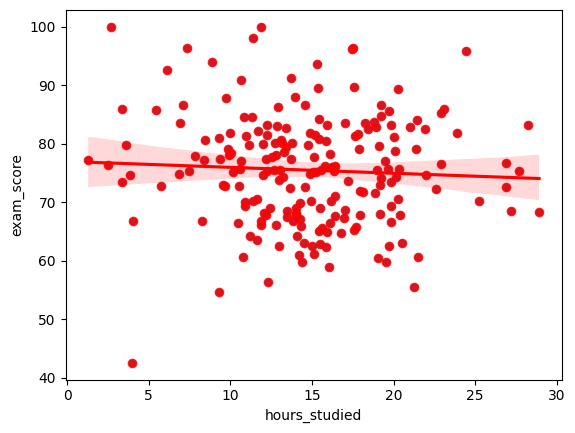

In [43]:
# Task 2: Relationship Visualization (8 points)
# TODO: Create a scatter plot of hours_studied vs exam_score

sns.scatterplot(x='hours_studied', y='exam_score', data=df)
# TODO: Add a regression line
sns.regplot(x='hours_studied', y='exam_score', data=df, color ='red', label = 'line')


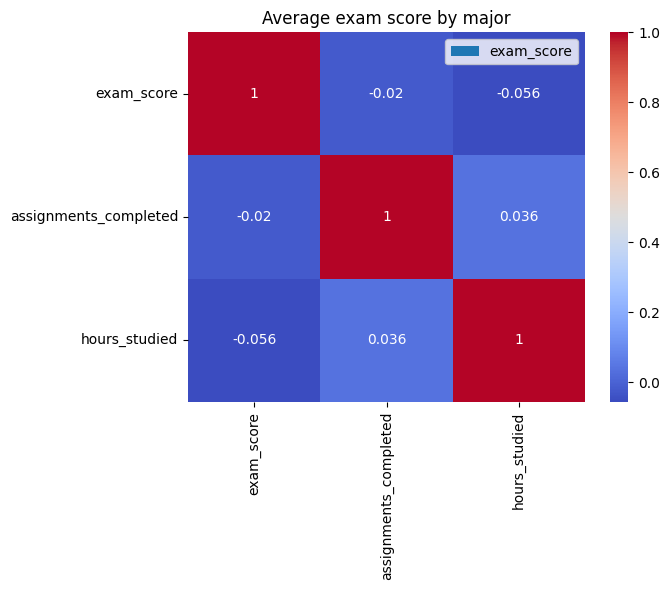

In [48]:
# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major

average_exam_score= df.groupby('major')['exam_score'].mean()
average_exam_score.plot(kind='bar', title='Average exam score by major')
#       2. Count plot: Number of students by year

sns.countplot(x='year', data=df)

#       3. Heat map: Correlation matrix of numerical columns

colunms =['exam_score', 'assignments_completed', 'hours_studied']
corr= df[colunms].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
#       4. Violin plot: Exam score distribution by performance category

performance_category=['Excellent', 'Good', 'Average', 'Needs Improvement']
df['performance_category']=pd.cut(df['exam_score'], bins=[0, 70, 80, 90, 100], labels=performance_category)



           number_customers  average_income  average_CLV      total_CLV
age_group                                                              
18-25                    69    51805.879852   704.492597   48609.989225
26-35                    73    48747.148046   747.738562   54584.915035
36-50                   160    48516.895668   732.796612  117247.457917
51-70                   186    50713.163384   762.693498  141860.990683
     age        income  purchase_frequency  avg_purchase_value  churn_risk  \
426   42  68713.567863                   8          154.285448    0.333333   
213   41  45580.608009                   7          164.920221    0.416667   
410   44  49344.934596                   6          177.097211    0.500000   
194   44  57331.964922                   6          176.640590    0.500000   
244   28  29255.076913                   7          159.784979    0.416667   
423   43  34443.666248                   6          173.245130    0.500000   
386   63  24200.782005

/tmp/ipykernel_17806/438981937.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_stats=customers.groupby('age_group').agg(number_customers=('age', 'count'),
/tmp/ipykernel_17806/438981937.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_CLV_by_age_group = customers.groupby('age_group')['CLV'].mean()


<Axes: title={'center': 'Average CLV by Age Group'}>

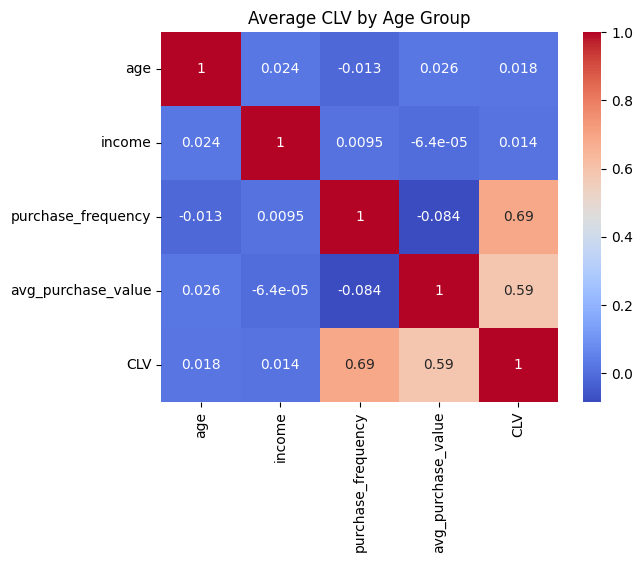

In [65]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})


# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)



max_frequency=customers['purchase_frequency'].max()
customers['churn_risk']=1-(customers['purchase_frequency']/max_frequency)
customers['CLV']=customers['purchase_frequency']*customers['avg_purchase_value']*(1+customers['churn_risk'])



# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70
age_bins = [18, 25, 35, 50, 70]
age_labels = ['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = pd.cut(customers['age'], bins=age_bins, labels=age_labels)


# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV


age_group_stats=customers.groupby('age_group').agg(number_customers=('age', 'count'),
                                                    average_income=('income', 'mean'),
                                                    average_CLV=('CLV', 'mean'),
                                                    total_CLV=('CLV', 'sum'))
print(age_group_stats)

# TODO: Identify top 10% of customers by CLV
top_10_percent_customers = customers.nlargest(int(0.1 * len(customers)), 'CLV')
print(top_10_percent_customers)

# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
sns.scatterplot(x='income', y='CLV', hue='age_group', data=customers, ax=axes[0], alpha=0.6)
axes[0].set_title('Income vs CLV (color by age group)')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('CLV')
axes[0].legend(title='Age Group')


#       2. Bar chart of average CLV by age group
average_CLV_by_age_group = customers.groupby('age_group')['CLV'].mean()
average_CLV_by_age_group.plot(kind='bar', title='Average CLV by Age Group')
#       3. Correlation heatmap

numeric_cols =  ['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']
corr = customers[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations